Default Accuracy: 0.8182004299314157
Confusion Matrix (Default):
 [[6782  632]
 [1144 1211]]

Best Accuracy: 0.8332480294810114
Best Number of Estimators: 200

Confusion Matrix (Best Model):
 [[7028  386]
 [1243 1112]]


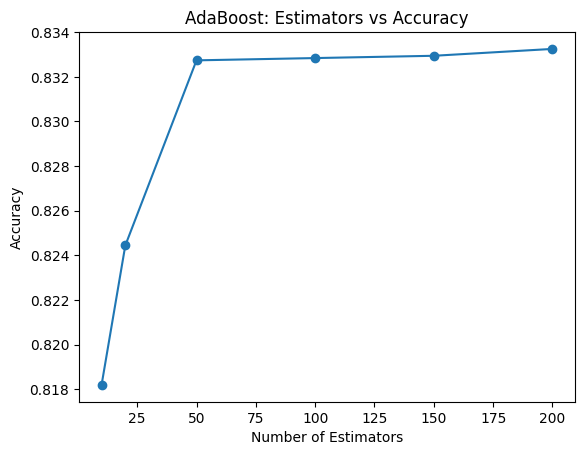

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("/content/income.csv")

X = df.drop("income_level", axis=1)
y = df["income_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ada_default = AdaBoostClassifier(n_estimators=10, random_state=42)
ada_default.fit(X_train, y_train)

y_pred_default = ada_default.predict(X_test)

print("Default Accuracy:", accuracy_score(y_test, y_pred_default))
print("Confusion Matrix (Default):\n", confusion_matrix(y_test, y_pred_default))


estimator_values = [10, 20, 50, 100, 150, 200]
accuracy_list = []

for n in estimator_values:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

best_accuracy = max(accuracy_list)
best_estimators = estimator_values[accuracy_list.index(best_accuracy)]

print("\nBest Accuracy:", best_accuracy)
print("Best Number of Estimators:", best_estimators)

ada_best = AdaBoostClassifier(n_estimators=best_estimators, random_state=42)
ada_best.fit(X_train, y_train)

y_pred_best = ada_best.predict(X_test)

print("\nConfusion Matrix (Best Model):\n", confusion_matrix(y_test, y_pred_best))


plt.plot(estimator_values, accuracy_list, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost: Estimators vs Accuracy")
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

df = pd.read_csv("/content/iris (2).csv")

X = df.select_dtypes(include=['float64', 'int64'])

k = 3

kmeans = KMeans(n_clusters=k, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_

df['Cluster'] = labels

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        1
2           4.7          3.2           1.3          0.2  Iris-setosa        1
3           4.6          3.1           1.5          0.2  Iris-setosa        1
4           5.0          3.6           1.4          0.2  Iris-setosa        1


In [7]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,0
146,6.3,2.5,5.0,1.9,Iris-virginica,2
147,6.5,3.0,5.2,2.0,Iris-virginica,0
148,6.2,3.4,5.4,2.3,Iris-virginica,0
